In [1]:
CASE = "R1P1"

from adrienParamSpectra import get
from scipy.io import netcdf_file  # avoids the deprecation warning

c = get(CASE)

nc = netcdf_file(str(c.file()), mode="r")  # read-only
print("Opened:", c.file())

Opened: /lustre/orion/cfd135/proj-shared/Hsst/R1P1/SpectraAdrien/wwspec_1100.000000.nc


In [2]:
list(nc.variables.keys())

['kx',
 'ky',
 'kz',
 'time',
 'ww_x',
 'ww_y',
 'ww_z',
 'pBdwdz_x',
 'pBdwdz_y',
 'pBdwdz_z',
 'pNLdwdz_x',
 'pNLdwdz_y',
 'pNLdwdz_z',
 'pSdwdz_x',
 'pSdwdz_y',
 'pSdwdz_z',
 'nudwdw_x',
 'nudwdw_y',
 'nudwdw_z']

In [3]:
# Check that the max wavenumber matches Nyquist cut off based on grid size
import numpy as np

kx = np.array(nc.variables["kx"][:]).squeeze()
ky = np.array(nc.variables["ky"][:]).squeeze()
kz = np.array(nc.variables["kz"][:]).squeeze()

kx_max = float(np.max(kx))
ky_max = float(np.max(ky))
kz_max = float(np.max(kz))

expected = c.Nx / 8
tol = 1e-12  # plenty strict for floats

ok = (
    abs(kx_max - expected) < tol and
    abs(ky_max - expected) < tol and
    abs(kz_max - expected) < tol
)

if ok:
    print(f"✓ kx, ky, kz all match Nx/8 = {expected}")
else:
    print("✗ mismatch:")
    print(f"  max(kx) = {kx_max}, diff = {kx_max - expected}")
    print(f"  max(ky) = {ky_max}, diff = {ky_max - expected}")
    print(f"  max(kz) = {kz_max}, diff = {kz_max - expected}")

✓ kx, ky, kz all match Nx/8 = 192.0


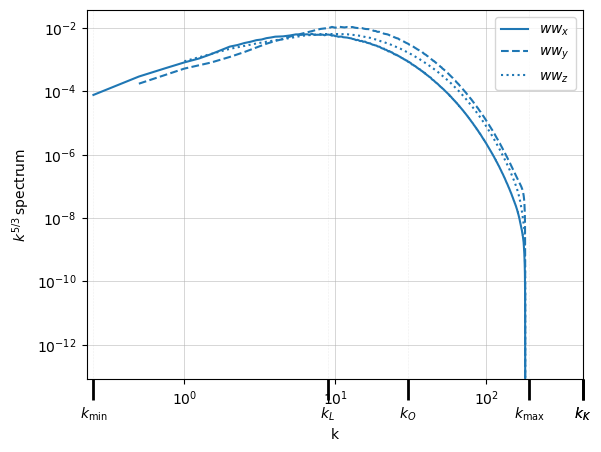

In [19]:
import numpy as np
import matplotlib.pyplot as plt

wwx = np.array(nc.variables["ww_x"][:]).squeeze()
wwy = np.array(nc.variables["ww_y"][:]).squeeze()
wwz = np.array(nc.variables["ww_z"][:]).squeeze()

# scales from registry
kmin = c.kmin
kB   = c.kB
kK   = c.kK
kO   = c.kO
kL   = c.kL
kmax = c.kmax

# trim (drop k=0 and last bin)
kx_, wwx_ = kx[1:-1], wwx[1:-1]
ky_, wwy_ = ky[1:-1], wwy[1:-1]
kz_, wwz_ = kz[1:-1], wwz[1:-1]

# compensated spectra: multiply by k^(5/3)
p = 5/3
wwx_comp = wwx_ * (kx_ ** p)
wwy_comp = wwy_ * (ky_ ** p)
wwz_comp = wwz_ * (kz_ ** p)

fig, ax = plt.subplots()

ax.loglog(kx_, wwx_comp, color="C0", linestyle="-",  label=r"$ww_x$")
ax.loglog(ky_, wwy_comp, color="C0", linestyle="--", label=r"$ww_y$")
ax.loglog(kz_, wwz_comp, color="C0", linestyle=":",  label=r"$ww_z$")

ax.set_xlim(kmin*0.9, kmax*1.2)

ax.set_xticks([kmin, kB, kK, kO, kL, kmax], minor=True)
ax.set_xticklabels(
    [r"$k_{\min}$", r"$k_B$", r"$k_K$", r"$k_O$", r"$k_L$", r"$k_{\max}$"],
    minor=True
)
ax.tick_params(axis="x", which="minor", length=15, width=2)

ax.set_xlabel("k")
ax.set_ylabel(r"$k^{5/3}\,\mathrm{spectrum}$")
ax.legend()

ax.grid(True, which="major", linestyle="-", linewidth=0.6, alpha=0.6)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, alpha=0.4)

plt.show()

In [14]:
kB



433.9466111433384